In [3]:
import salishsea_tools
import os
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import netCDF4 as nc
from salishsea_tools import geo_tools

OUTPATH = '/ocean/ghoeven/MOAD/analysis-griffon/ResTimeOutput/'

In [4]:
# Only change these and then run the rest
regionName = 'AdmiraltyInlet30d'
folderName = 'AdmiraltyInlet_30d'
outputf = '/ocean/ghoeven/MOAD/analysis-griffon/Ariane/'+folderName+'/new_compw_forward_01jan18/ariane_positions_quantitative.nc'
# outputf = '/ocean/ghoeven/MOAD/analysis-griffon/Ariane/'+folderName+'/new_compw_forward_01jul18/ariane_positions_quantitative.nc'

dataf = xr.open_dataset(outputf)

/tmp/ipykernel_2502230/856906455.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dataf = xr.open_dataset(outputf)


In [5]:
# Setting up output directories and input names
path = OUTPATH + regionName
if not os.path.exists(path):
  os.mkdir(path)
  print("Folder %s created" % path)
else:
  print("Folder %s already exists" % path)

Folder /ocean/ghoeven/MOAD/analysis-griffon/ResTimeOutput/AdmiraltyInlet30d created


In [8]:
fage

<xarray.DataArray 'final_age' (ntraj: 230755)> Size: 2MB
array(['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
      shape=(230755,), dtype='timedelta64[ns]')
Dimensions without coordinates: ntraj
Attributes:
    title:     What is fial_age ?
    longname:  Final Age.

ValueError: autodetected range of [nan, nan] is not finite

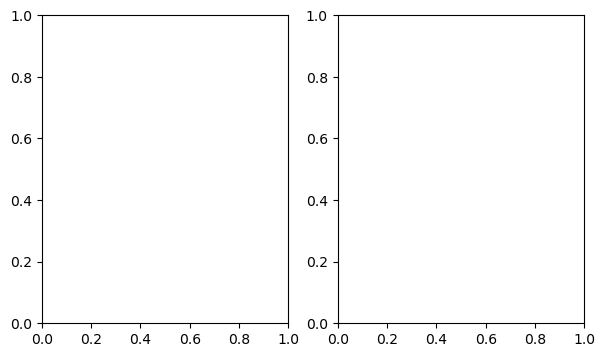

In [7]:
# Plot and save histogram

fage = dataf.final_age
fage_days = fage.values / np.timedelta64(1, 'h')
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 4))
ax[0].hist(fage_days, bins=60, log=False, )
ax[0].set_xlabel('Hours after seeding')
ax[0].set_ylabel(f'# Particles Leaving {regionName}')

ax[1].hist(fage_days, bins=60, log=True, )
ax[1].set_xlabel('Hours after seeding')
ax[1].set_ylabel(f'# Particles Leaving {regionName} (log)')
fig.suptitle(f'Time Particles Spend in {regionName}')
plt.tight_layout()
plt.savefig(path+'/'+'RawHist')

fage_day1 = fage_days[~(fage_days > 24)]
fig, ax = plt.subplots(figsize=(4, 4))
ax.hist(fage_day1, bins=60, log=False, )
ax.set_title(f'Time Particle Spends in {regionName} (First Day)')
ax.set_xlabel('Hours after seeding')
ax.set_ylabel(f'# Particles Leaving {regionName} (log)')

plt.savefig(path+'/'+'FirstDayHist')

In [ ]:
# Filtered value histogram and saved
fin_age = dataf.final_age.values / np.timedelta64(1, 'h')

tide_filter = ~((fin_age <= 24))
tide_filter = xr.DataArray(tide_filter, dims=['ntraj'])
# print(type(tide_filter))
fage_filtered = fin_age[tide_filter]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 4))
ax[0].hist(fage_filtered, bins=60, log=False, )
ax[0].set_xlabel('Hours after seeding')
ax[0].set_ylabel(f'# Particles Leaving {regionName}')

ax[1].hist(fage_filtered, bins=60, log=True, )
ax[1].set_xlabel('Hours after seeding')
ax[1].set_ylabel(f'# Particles Leaving {regionName} (log)')
fig.suptitle(f'Time Particles Spend in {regionName} (filtered)')
plt.tight_layout()
plt.savefig(path+'/'+'RawHist_filtered')

fage_day1_filt = fage_filtered[~(fage_filtered > 24)]
fig, ax = plt.subplots(figsize=(4, 4))
ax.hist(fage_day1_filt, bins=60, log=False, )
ax.set_title(f'Time Particle Spends in {regionName} (First Day, filtered)')
ax.set_xlabel('Hours after seeding')
ax.set_ylabel(f'# Particles Leaving {regionName} (log)')

plt.savefig(path+'/'+'FirstDayHist_filtered')


In [ ]:
# Save stats in txt
print('Day 1 mean time (h)        = ' + str(np.mean(fage_day1)))
print('Day 1 stdev of time in (h) = ' + str(np.std(fage_day1)))
print('Total mean time in (h)     = ' + str(np.mean(fage_days)))
print('Total stdev of time in (h) = ' + str(np.std(fage_days)))
print('Filtered Stats:')
print('Day 1 mean time (h) = ' + str(np.mean(fage_day1_filt)))
print('Total mean time in (h) = ' + str(np.mean(fage_filtered)))

with open(path+'/'+"outputStats.txt", "w") as file:
    file.write('\nDay 1 mean time (h)        = ' + str(np.mean(fage_day1)))
    file.write('\nDay 1 stdev of time in (h) = ' + str(np.std(fage_day1)))
    file.write('\nTotal mean time in (h)     = ' + str(np.mean(fage_days)))
    file.write('\nTotal mean time in (d)     = ' + str(np.mean(fage_days)/24))
    file.write('\nTotal stdev of time in (h) = ' + str(np.std(fage_days)))
    file.write('\n\nFiltered Data Stats')
    file.write('\nDay 1 mean time (h) = ' + str(np.mean(fage_day1_filt)))
    file.write('\nTotal mean time in (h) = ' + str(np.mean(fage_filtered)))
    file.write('\nTotal mean time in (d) = ' + str(np.mean(fage_filtered)/24))